# Chapter 8

Add your content here.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data (The Physics World)
def generate_trajectory(num_points=100):
    # A ball moving in a sine wave
    x = np.linspace(0, 4*np.pi, num_points)
    y = np.sin(x)
    
    # Create "Pixel" representations (One-hot vectors)
    # The world is a grid of size 20
    grid_size = 20
    data = []
    
    for val in y:
        # Normalize sine (-1 to 1) to grid index (0 to 19)
        idx = int((val + 1) / 2 * (grid_size - 1))
        # Create a vector of zeros with a 1 at the ball's position
        frame = np.zeros(grid_size)
        frame[idx] = 1.0 
        data.append(frame)
        
    return torch.tensor(np.array(data), dtype=torch.float32)

# Create a batch of data
data = generate_trajectory()
print(f"Data Shape: {data.shape}") # (100, 20) -> 100 timesteps, 20 pixels

Data Shape: torch.Size([100, 20])


In [2]:
# 2. Define the Architecture

class ContextEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        # Compresses high-dim pixels to low-dim latent vector
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.net(x)

class Predictor(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # Predicts the NEXT latent vector based on CURRENT latent vector
        # (Modeling the physics of the sine wave)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim) 
        )
        
    def forward(self, s_x):
        return self.net(s_x)

# Hyperparameters
INPUT_DIM = 20   # The grid size (pixels)
LATENT_DIM = 2   # We compress the world into just 2 numbers!

encoder = ContextEncoder(INPUT_DIM, LATENT_DIM)
predictor = Predictor(LATENT_DIM)

optimizer = optim.Adam(list(encoder.parameters()) + list(predictor.parameters()), lr=0.01)
loss_fn = nn.MSELoss()

Epoch 0: Loss 0.0933
Epoch 100: Loss 0.0076
Epoch 200: Loss 0.0336
Epoch 300: Loss 0.1240
Epoch 400: Loss 0.1242


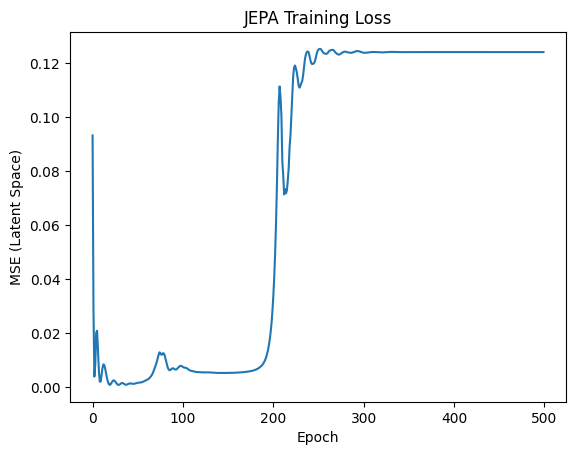

In [3]:
# 3. Training Loop
losses = []

for epoch in range(500):
    # Prepare inputs (x) and targets (y)
    # x is current frame, y is next frame
    x = data[:-1] # All frames except last
    y = data[1:]  # All frames except first
    
    # --- Forward Pass ---
    
    # 1. Encode the target (future)
    # In full JEPA, this uses a separate Target Encoder. 
    # Here we share weights for simplicity.
    s_y_target = encoder(y).detach() # STOP GRADIENT: We don't update encoder via target path here
    
    # 2. Encode the context (current)
    s_x = encoder(x)
    
    # 3. Predict the future in latent space
    s_y_pred = predictor(s_x)
    
    # 4. Calculate Loss in Latent Space
    loss = loss_fn(s_y_pred, s_y_target)
    
    # --- Backward Pass ---
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.4f}")

# Visualization of Loss
plt.plot(losses)
plt.title("JEPA Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (Latent Space)")
plt.show()